# **Scikit-Learn Demo**
This notebook will utilize some of the key functionality of the SciKit-Learn module including pre-processing and modeling. 
 
[Scikit learn](https://scikit-learn.org/stable/) is a popular data science library that is great for implementing basic machine learning models. With very little code you can create various supervised and unsupervised models. It also has lots of great tools for pre-processing, model selection/evaluation, visualizations, and more. It really is a one stop shop for everything data science. 

## Import Libraries

Import the libraries that we will be using. You may need to install these, mainly the `scikit-learn` one if you do not have them in your environment already.

In [1]:
#!pip install scikit-learn

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import tree # This is the ML model we will use today.

## Load Data

The data was accessed from [Charlotte's Data Portal](https://data.charlottenc.gov/datasets/charlotte::housing-demand-and-availability-by-income/about) and its source is the [2018 American Community Survey (ACS)](https://www2.census.gov/programs-surveys/acs/tech_docs/pums/ACS2014_2018_PUMS_README.pdf). 

It is a subset of the American Community Survery containing only data about Charlotte households. It contains features about households such a number of rooms, baths, etc. As well as information about those living in the houses such as income, number of children, and more. 

To simplify the demo, the dataset has already been cleaned and a subset of useful columns has been selected. In a real project, data cleaning and feature selection would typically be part of the workflow.

The data is in table format and contains the following features:
- **TEN**: Type of Tenure (Categorical String) 
- **NP**: Number of people living in the household (Numerical Int)
- **NOC**: Number of children living in the household (Numerical Int)
- **HHT**: Household Type (Categorical String) 
- **LNGI**: Limited english speaking household (Boolean Int) 
- **HINCP**: Annual household income (Numerical Float)
- **RNTP**: Monthly rent (Numerical Float)
- **PUMA**: Geographical region (Categorical String)
- **COST_BURDALL**: Whether or not a household is cost burdened (Boolean Int)
- **RMSP**: The number of rooms in the household (Numerical Int)

<font color="red">TASK.</font>  
Download the dataset off Canvas and load it in.

In [3]:
# Read in the data
df = pd.read_csv(r"C:\Users\aashu\OneDrive\UNCC WORK\DTSC\2302\clt_housing_cleaned.csv")

<font color="red">**TASK**.</font>  
Before building a machine learning model, we need to understand our data. Start by answering the questions below:  
1. How many rows and columns are in the dataset?
2. What data types appear in this dataset?
3. Which columns seem like numerical features and which seem categorical? Write down at least two examples of each.
4. Which column do you think might be a good target variable for a machine learning model? Why?

Use the `pandas` methods necessary in code cells to help you answer these questions.

**DOUBLE CLICK TO TYPE IN YOUR RESPONSE**

In [4]:
print(df.shape)
print(df.dtypes)

(1418, 12)
TEN                 str
NP                int64
NOC             float64
HHT                 str
LNGI            float64
ELEP            float64
VEH             float64
HINCP           float64
RNTP            float64
PUMA                str
COST_BURDALL    float64
RMSP              int64
dtype: object


In [5]:
df.head()

,TEN,NP,NOC,HHT,LNGI,ELEP,VEH,HINCP,RNTP,PUMA,COST_BURDALL,RMSP
0,Rented,5,3.0,"Other family household: Female householder, no...",1.0,100.0,1.0,18000.0,800.0,Charlotte City (Northwest),1.0,5
1,Rented,1,0.0,Nonfamily household: Male householder: Living ...,1.0,120.0,1.0,72000.0,1100.0,Charlotte City (South),0.0,7
2,Rented,2,0.0,Married couple household,1.0,170.0,2.0,56600.0,600.0,Charlotte City (Central),0.0,5
3,Rented,4,2.0,Married couple household,1.0,80.0,2.0,59400.0,800.0,Charlotte City (Southwest),0.0,6
4,Rented,1,0.0,Nonfamily household: Male householder: Living ...,1.0,30.0,1.0,160000.0,1400.0,Charlotte City (Central),0.0,1


Num:
1. NP
2. NOC

Cat:
1. HHT
2. PUMA

Good response variable example:
- COST_BURDALL - You predict whether or not a household is cost burdened

## Data Understanding + Pre-Processing

Let's explore the data further and decide what cleaning steps need to be done.

In [6]:
df.head()

,TEN,NP,NOC,HHT,LNGI,ELEP,VEH,HINCP,RNTP,PUMA,COST_BURDALL,RMSP
0,Rented,5,3.0,"Other family household: Female householder, no...",1.0,100.0,1.0,18000.0,800.0,Charlotte City (Northwest),1.0,5
1,Rented,1,0.0,Nonfamily household: Male householder: Living ...,1.0,120.0,1.0,72000.0,1100.0,Charlotte City (South),0.0,7
2,Rented,2,0.0,Married couple household,1.0,170.0,2.0,56600.0,600.0,Charlotte City (Central),0.0,5
3,Rented,4,2.0,Married couple household,1.0,80.0,2.0,59400.0,800.0,Charlotte City (Southwest),0.0,6
4,Rented,1,0.0,Nonfamily household: Male householder: Living ...,1.0,30.0,1.0,160000.0,1400.0,Charlotte City (Central),0.0,1


Since we have a good amount of categorical variables, let's see how many bins each of them has.

In [7]:
for col in df.columns:
    print(f"{col}:\n {df[col].value_counts()}\n")

TEN:
 TEN
Rented    1418
Name: count, dtype: int64

NP:
 NP
1     550
2     444
3     199
4     140
5      61
6      15
7       5
8       2
9       1
11      1
Name: count, dtype: int64

NOC:
 NOC
0.0    1048
1.0     167
2.0     132
3.0      51
4.0      14
5.0       3
6.0       3
Name: count, dtype: int64

HHT:
 HHT
Married couple household                                         342
Nonfamily household: Female householder: Living alone            302
Other family household: Female householder, no spouse present    252
Nonfamily household: Male householder: Living alone              248
Nonfamily household: Male householder: Not living alone          108
Nonfamily household: Female householder: Not living alone         93
Other family household: Male householder, no spouse present       73
Name: count, dtype: int64

LNGI:
 LNGI
1.0    1318
2.0     100
Name: count, dtype: int64

ELEP:
 ELEP
100.0    168
80.0     143
70.0     117
60.0     108
90.0     104
50.0     103
120.0     90
150.0 

Does anything stand out when looking at this? 

We see that **TEN** (tenure) only contained one possible value. This makes that whole feature redudant in this case since it acts as a constant that doesn't give any real information. 

We can also get some hints about the distribution of each feature by looking at the quantities of each unique value. For example we can see the **VEH** is leftward skewed. 

Let's go ahead and drop the TEN feature and then continue to explore the distributions, using visualizations. 

In [8]:
#dropping TEN
df.drop(columns = ['TEN'], inplace = True)

Before training a machine learning model, it is important to explore and understand the dataset.

One useful visualization for exploring relationships between variables is a pairplot.
A pairplot allows us to quickly see:

- how variables relate to each other
- the distribution of each feature
- potential patterns or correlations

The plots on the diagonal show the distribution of each variable, while the off-diagonal plots show pairwise relationships between features.

<font color="red">TASK.</font>  
Use `seaborn` to create a pairplot below. Then discuss and answer:  
1. What do you notice about the distributions of the features?
2. Do you see any relationships or patterns between variables? For example: Do households with more people tend to have more rooms? Do any variables appear correlated?

**DOUBLE CLICK TO TYPE IN YOUR RESPONSE**

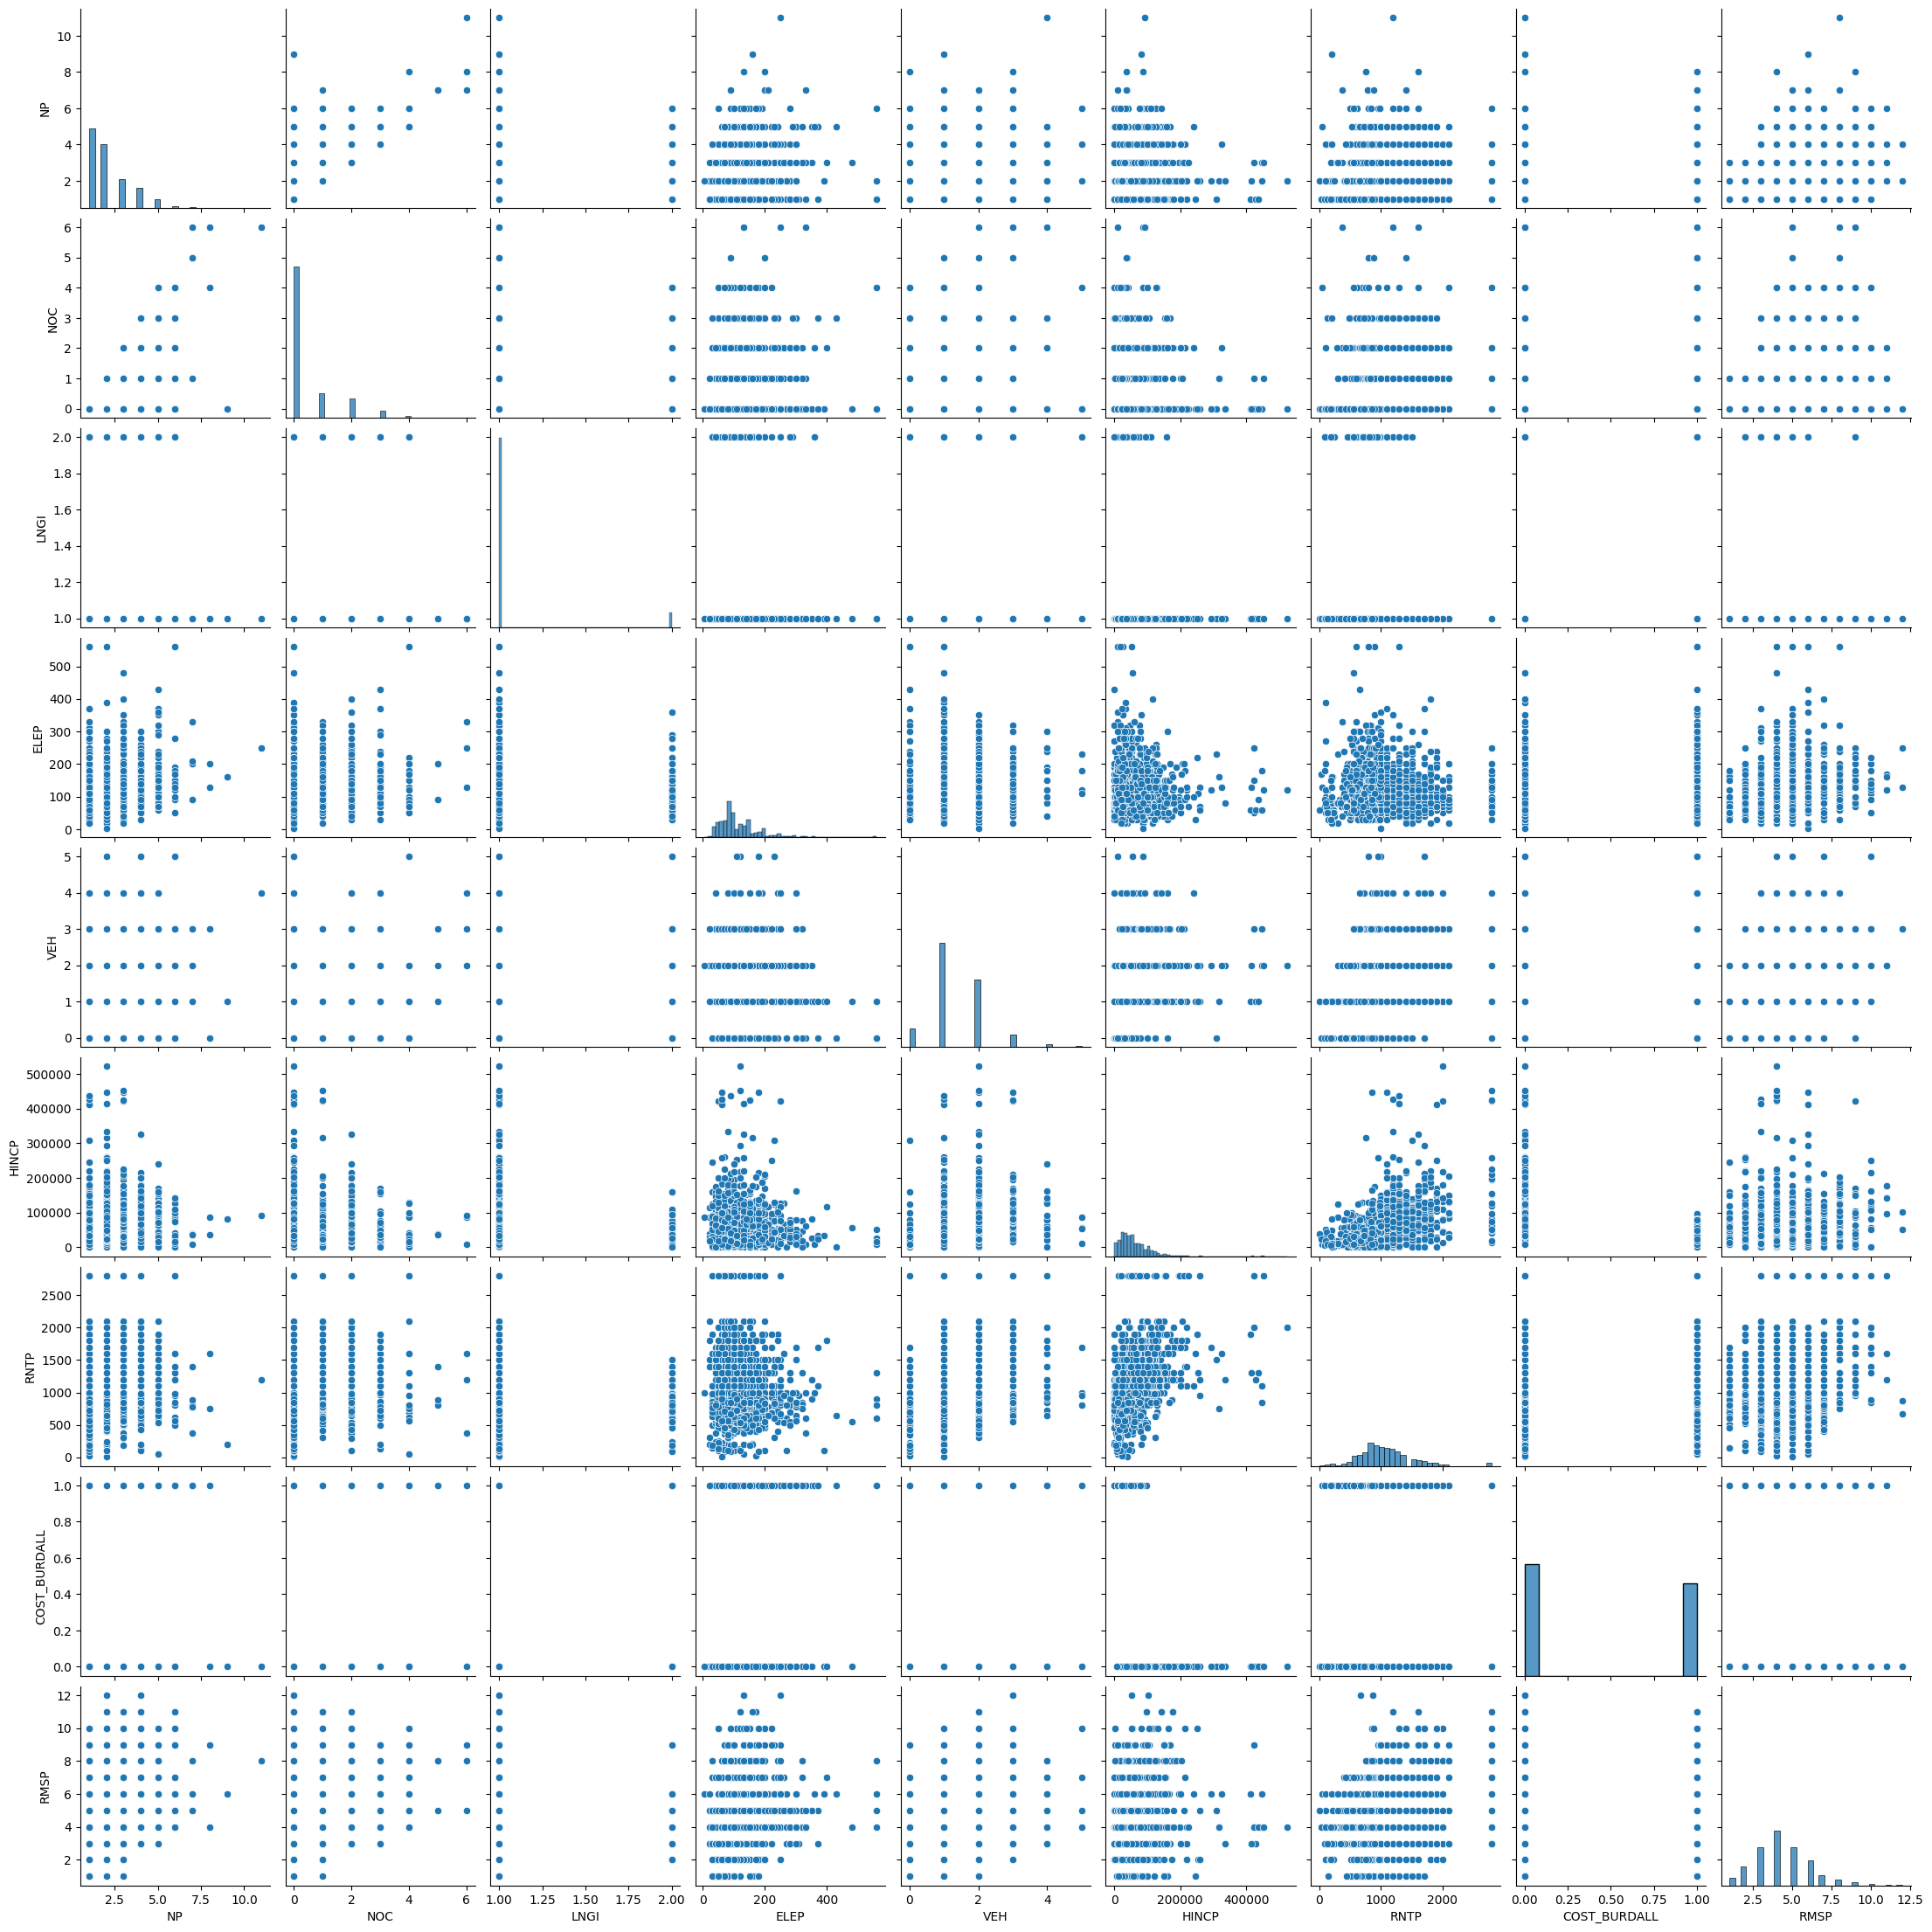

In [9]:
# WRITE YOUR CODE HERE
sns.pairplot(df)
plt.show()

We can see some skew in several feature distributions. In some cases, data transformations can help improve model performance or satisfy assumptions made by certain algorithms.

Additionally, some columns in this dataset contain categorical values (strings). Many machine learning algorithms operate on numerical data. Because of this, categorical variables (such as strings) typically need to be converted into a numeric representation before training a model.

Another thing we can see is that **our numerical values are not all in the same unit**. HINCP (household income) is a yearly value whereas ELEP (electriciy bill) and RNTP (rent) are monthly. Let's convert HINCP to monthly. 

<font color="red">TASK.</font>  
Write a line of code below to convert `HINCP` (household income) to a monthly value to stay consistent with `RNTP` (rent) and `ELEP` (electric bill).

In [10]:
# WRITE YOUR CODE HERE
df['HINCP'] = df['HINCP'] / 12
df.head()

,NP,NOC,HHT,LNGI,ELEP,VEH,HINCP,RNTP,PUMA,COST_BURDALL,RMSP
0,5,3.0,"Other family household: Female householder, no...",1.0,100.0,1.0,1500.000000,800.0,Charlotte City (Northwest),1.0,5
1,1,0.0,Nonfamily household: Male householder: Living ...,1.0,120.0,1.0,6000.000000,1100.0,Charlotte City (South),0.0,7
2,2,0.0,Married couple household,1.0,170.0,2.0,4716.666667,600.0,Charlotte City (Central),0.0,5
3,4,2.0,Married couple household,1.0,80.0,2.0,4950.000000,800.0,Charlotte City (Southwest),0.0,6
4,1,0.0,Nonfamily household: Male householder: Living ...,1.0,30.0,1.0,13333.333333,1400.0,Charlotte City (Central),0.0,1


Let's also go ahead and convert our categorical variables to numerical. 

There are two common methods for doing this encoding. We could convert each category to an integer (1 to n-1 : where n is the number of features) or we could create a new column for each value (OneHot Encoding) in which contains boolean values. The first option is good for when the data is ordinal but when order is arbitrary we typically use OneHot encoding. 

You can perform OneHot encoding with sklearn, however it is much simpler to do so with Pandas. 

[User guide for preprocessing with sklearn ](https://scikit-learn.org/stable/modules/preprocessing.html)

<font color="red">TASK.</font>  
Write in the code cell below to perform this pre-processing task. Perform OneHot encoding on the columns `HHT` and `PUMA`.

In [11]:
# WRITE YOUR CODE HERE
df = pd.get_dummies(df, columns=['HHT', 'PUMA'], drop_first=True)

In [12]:
df.head()

,NP,NOC,LNGI,ELEP,VEH,HINCP,RNTP,COST_BURDALL,RMSP,HHT_Nonfamily household: Female householder: Living alone,...,HHT_Nonfamily household: Male householder: Not living alone,"HHT_Other family household: Female householder, no spouse present","HHT_Other family household: Male householder, no spouse present",PUMA_Charlotte City (Northeast),PUMA_Charlotte City (Northwest),PUMA_Charlotte City (South),PUMA_Charlotte City (Southwest),PUMA_Mecklenburg County (East)--Mint Hill & Matthews (North) Towns,"PUMA_Mecklenburg County (North)--Huntersville, Cornelius & Davidson Towns",PUMA_Mecklenburg County (South)--Matthews Town (South)
0,5,3.0,1.0,100.0,1.0,1500.000000,800.0,1.0,5,False,...,False,True,False,False,True,False,False,False,False,False
1,1,0.0,1.0,120.0,1.0,6000.000000,1100.0,0.0,7,False,...,False,False,False,False,False,True,False,False,False,False
2,2,0.0,1.0,170.0,2.0,4716.666667,600.0,0.0,5,False,...,False,False,False,False,False,False,False,False,False,False
3,4,2.0,1.0,80.0,2.0,4950.000000,800.0,0.0,6,False,...,False,False,False,False,False,False,True,False,False,False
4,1,0.0,1.0,30.0,1.0,13333.333333,1400.0,0.0,1,False,...,False,False,False,False,False,False,False,False,False,False


At this point we can go ahead and implement a model using SK-Learn. Since we are covering classification this week, let's implement a decision tree.

Side note: Many models require standardization of data, decision trees are an exception due to how they are constructed. 

## **Modeling**
- Decision Tree: https://scikit-learn.org/stable/modules/tree.html
- Cross Validation: https://scikit-learn.org/stable/modules/cross_validation.html

Before we jump into modeling we first need to identify our target or independent variable. Meaning the feature in-which we wish to predict. 

In this case, let's explore how well our available household features could predict whether a household is cost-burdened or not. Remember cost-burdened is simply a binary value which is perfectly suited for classification. 

<font color="red">TASK.</font>  
Let's separate our data into a dependent (X) and independent (y) set. Write the code below.  

In [13]:
X = df.drop(columns = ['COST_BURDALL'])
y = df['COST_BURDALL']

### Train our first model!

We will be implementing a decision tree model for this demo, we will learn more about how this model in particular works soon!

In [14]:
from sklearn import tree # Import the tree model

In [15]:
clf = tree.DecisionTreeClassifier() #instantiate Decision Tree class

<font color="red">TASK.</font>  
Write code below to train our first model!


In [16]:
clf = clf.fit(X, y) #fit the model to the data

Next, we want to see how well our model did!

In [17]:
#predict values from X_test
predicted = clf.predict(X)
predicted[:100] # Look at just the first 100 predictions

array([1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1., 0.,
       1., 1., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0.,
       1., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1.,
       1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0.,
       1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1.])

The values are all 0s and 1s as expected

In [18]:
y[:100]

0     1.0
1     0.0
2     0.0
3     0.0
4     0.0
     ... 
95    0.0
96    0.0
97    0.0
98    1.0
99    1.0
Name: COST_BURDALL, Length: 100, dtype: float64

In [19]:
pd.DataFrame({
    "Predicted": predicted[:20],
    "Actual": y[:20].to_numpy()
})

,Predicted,Actual
0,1.0,1.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
5,0.0,0.0
6,0.0,0.0
7,0.0,0.0
8,1.0,1.0
9,0.0,0.0


<font color="red">TASK.</font>  
Evaluate the model's performance using the `score` method.

In [20]:
# WRITE YOUR CODE HERE
clf.score(X, y)

1.0

<font color="red">TASK.</font>  
What do you notice about the score?
The model achieved extremely high accuracy.

Discuss with your groups and answer:

1. Does this mean our model is excellent?
2. Why might evaluating a model on the same data it was trained on be misleading?
3. What might happen if we applied this model to **new unseen data**?

**DOUBLE CLICK TO TYPE IN YOUR RESPONSE**
1. No, the model is likely overfitting on the training data.
2. The model will have memorized the pattern in the training data and will not be able to generalize to new data.
3. The model will perform very poorly.

### Train Test Split

We need to split our dataset into a training and testing subset!

<font color="red">TASK.</font>  
Make the split! By the end, we should have an `X_train`, `X_test`, `y_train`, and `y_test`. Set 80% of the dataset for the training set, and the remaining 20% for the testing set.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (1134, 21)
X_test (284, 21)
y_train (1134,)
y_test (284,)


Now that our data is split, let's train our model properly.

In [23]:
clf = tree.DecisionTreeClassifier() #instantiate Decision Tree class

<font color="red">TASK.</font>  
Write code below to train our model using our training subset.

In [24]:
clf = clf.fit(X_train, y_train) #fit the model to the data

And just like that... the model is trained!

How is it performing?

## Inspection and Evaluation

Feature Importance: https://scikit-learn.org/stable/modules/permutation_importance.html  
Evaluation Metrics: https://scikit-learn.org/stable/modules/model_evaluation.html

<font color="red">TASK.</font>  
Evaluate the model's performance using the `score` method.

In [25]:
clf.score(X_test, y_test)

0.9366197183098591

Wow! That’s a very high accuracy score. While this sounds promising, we should always be cautious when a model performs extremely well. High accuracy can sometimes indicate issues such as **overfitting** or strong correlations in the current data that may not generalize to new datasets.

One advantage of **decision trees** is that they are considered *white-box models*, meaning we can inspect the rules the model learned. Unlike many other machine learning models, we can directly visualize the decision process.

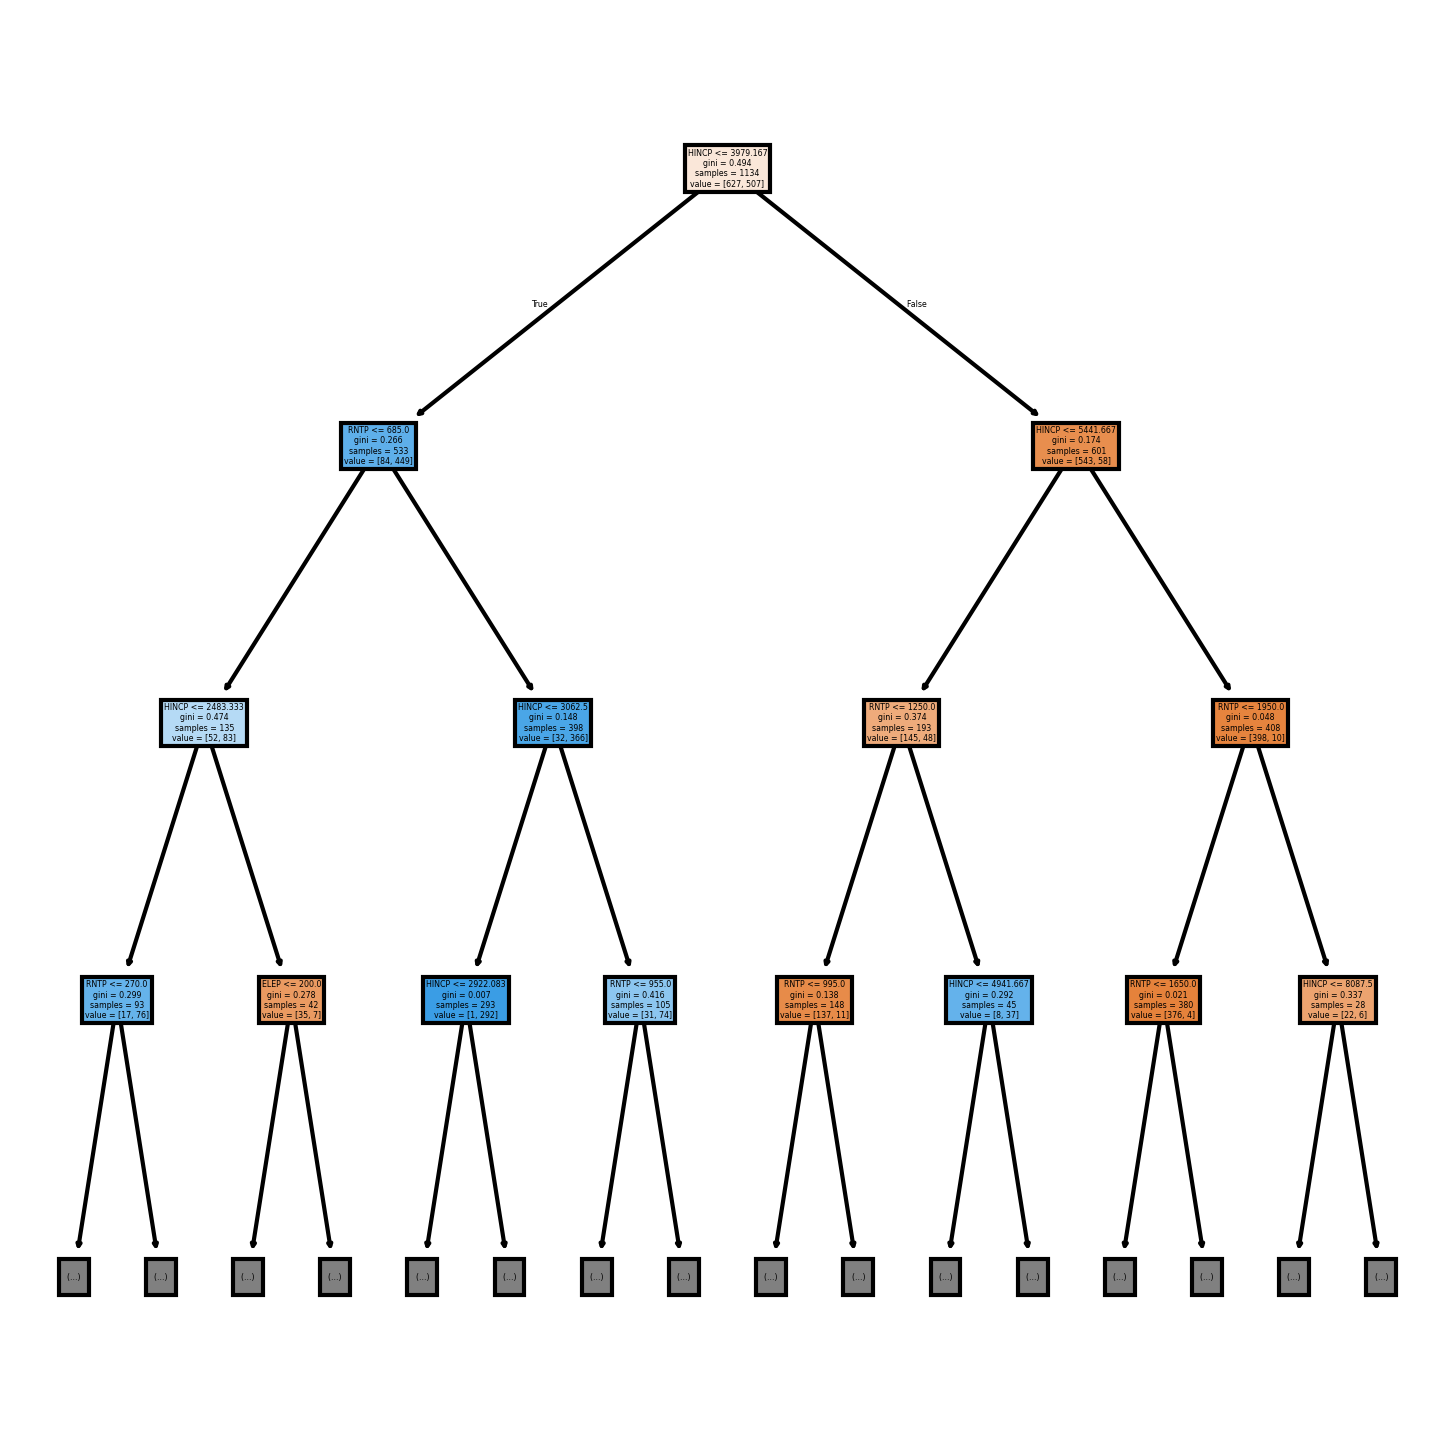

In [26]:
fig, axes = plt.subplots(nrows = 1,ncols = 1, figsize = (6,6), dpi=300)
tree.plot_tree(clf, max_depth = 3, feature_names = X.columns, filled=True)
plt.show()

<font color="red">TASK.</font>  
Take a moment to inspect the decision tree.

Discuss with your groups and answer:

1. Which **feature** does the model split on at the **root node** (the very top of the tree)?
2. What does the **threshold value** represent in that split?
3. What do the **colors** of the nodes indicate?
4. What does the **gini** value represent?
5. What does the **samples** value represent?
6. Based on the tree, what factors seem most related to whether a household is **cost burdened**?

**DOUBLE CLICK TO TYPE IN YOUR RESPONSE**
1. HINCP.
2. It represents the threshold value the node is split on.
3. They represent the majority class (COST burdened or not) of the node and the darker the color the more samples in the node.
4. Gini is the impurity value of the node based on class distribution.
5. The number of samples that are in the node.
6. HINCP, RNTP, and ELEP.

#### Let's verify the feature importance even further using a feature importance plot.

In [32]:
fi = clf.feature_importances_ #feature importance array
fi = pd.Series(data = fi, index = X.columns) #convert to Pandas series for plotting
fi.sort_values(ascending=False, inplace=True) #sort descending

C:\Users\aashu\AppData\Local\Temp\ipykernel_14876\3876163039.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


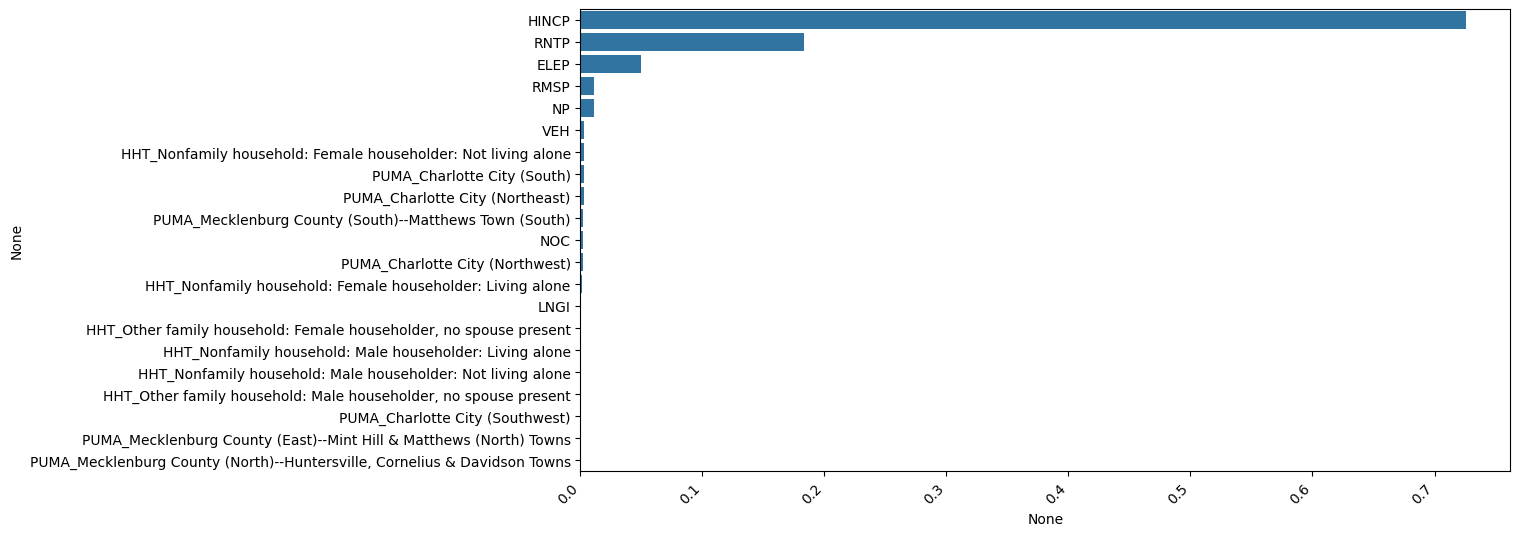

In [29]:
#create bar plot
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi, y=fi.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

As we can see, this aligns with what we saw in the tree. More than half of the features were essentially ignored. 

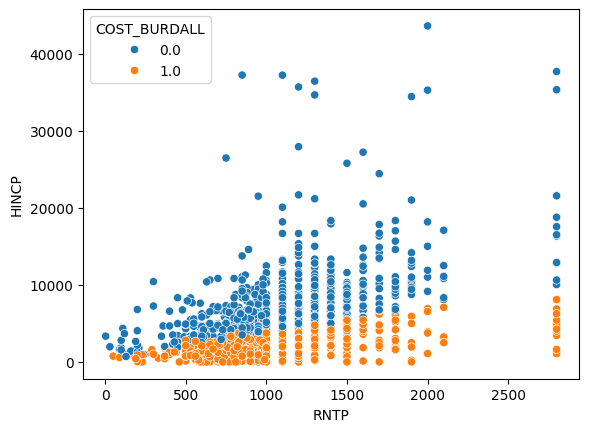

In [30]:
sns.scatterplot(data=df, x='RNTP', y='HINCP', hue = "COST_BURDALL")
plt.show()

Using the two most important features identified by our decision tree (**RNTP (rent)** and **HINCP (income)**) we can visualize how they relate to our target variable.

In this plot, we see that these two variables almost perfectly separate the two classes. This happens because **COST_BURDALL is derived from the ratio between rent and income**. In other words, these features are directly related to how the target variable is defined.

<font color="red">TASK.</font>  
What limitations might exist in using only these variables to understand housing burden?

1. You might be ignoring other features that may have a relationship with housing burden

### Next Time

Today we trained our first decision tree model and explored how features influence predictions.

In a future demo, we will:
- explore additional model evaluation techniques
- introduce cross validation
- experiment with different models and feature sets

These steps will help us build models that are more reliable and better at generalizing to new data.